# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

In [ ]:
!pip install gdown
!gdown --id 1ijm-HWhnDvuZNXvGhZQFx97TV89AYbFR -O requirements.txt

!pip install -r requirements.txt

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ijm-HWhnDvuZNXvGhZQFx97TV89AYbFR
To: /content/requirements.txt
100% 3.73k/3.73k [00:00<00:00, 19.0MB/s]
  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiohttp-3.12.15-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.7 kB)
  Using cached anyio-4.10.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached astor-0.8.1-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached asttokens-3.0.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached bitsandbytes-0.47.0-py3-none-manylinux_2_24_x86_64.whl.metadata (11 kB)
  Using cached blake3-1.0.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (217 by

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [ ]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.89 s (started: 2026-01-11 09:21:11 +00:00)


In [ ]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Tue Jan 13 09:43:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.
# TODO: Fill in the missing parts marked with **********

# Downgrade peft to a compatible version before importing unsloth
# This is necessary because unsloth 2026.1.2 seems to expect 'ensure_weight_tying'
# as an argument in LoraConfig, which is not present in peft 0.17.1.


import unsloth
from peft import LoraConfig, get_peft_model
from unsloth import FastLanguageModel
import torch, os

os.environ["TRITON_DISABLE_LINE_INFO"] = "1"

max_seq_length = 384  # Increase if you get errors about the sequence length


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.set_num_threads(max(1, os.cpu_count() // 2))
print(f"using device: {device}")

# The 'model.to(device)' line is likely causing an error if 'model' is not yet defined.
# This line should be moved after the model is loaded.
# Temporarily commenting out or adjusting if it's causing issues before model definition.
# For now, let's assume 'model' is not defined yet and the error is elsewhere,
# or that this line should be removed/moved based on typical unsloth usage.
# Given the traceback, the error is occurring during the import of unsloth,
# so 'model' would not yet be an issue.
# model.to(device) # This line will error if no GPU and model is not yet loaded.

# Set the LoRA rank to an appropriate value
# Read about setting LoRA rank:
# https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
lora_rank = 32 # Explain your choice: For capacity but moderate memory consumption

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=False,  # This uses vllm for faster inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  # You can reduce this if you get an memory error
)

# If device is not 'cpu', move the model to the detected device
#if device.type != 'cpu':
#   model.to(device)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        # Read about choosing adapters for LoRA:
        # https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
        # Choose the target modules/adapters for your LoRA model
        "q_proj", # for efficiency Targeting the Attention modules for information routing accros tokens [q_proj, k_proj, v_proj, o_proj]
        "k_proj", # for effectiveness, targerting the Multi Layer Perceptron (MLP) for knowledge storage [gate_proj,up_proj, down_proj]
        "v_proj", # combining both ensures LoRa adaptors captures contextual understanding and factual knowlegde, achieving performance close to full fine tuning
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank, # lora_rank or lora_rank * 2
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    ensure_weight_tying = False,
    # See: https://github.com/unslothai/unsloth
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 01-19 20:24:45 [__init__.py:241] Automatically detected platform cuda.
ERROR 01-19 20:24:46 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!
using device: cuda
==((====))==  Unsloth 2026.1.3: Fast Qwen2 patching. Transformers: 4.55.4. vLLM: 0.10.1.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Unsloth 2026.1.3 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [ ]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text_for_completion, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=2048,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(generated_text)

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
system

user
How many of the letter "g" are there in the word "engage"
assistant
In the word "engage", there is only one letter "g".


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [ ]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.
# TODO: Fill in the missing parts marked with **********
FastLanguageModel.for_inference(model)
# Use a CoT prompt with at least one example
SYSTEM_PROMPT = """You an AI assitant, always break down your task into steps. Analyze each steps with best practices, apply the best practice, test you solution, before given final solution.

Example 1
User Question: How many "g" are in engage
Steps
step 1: Split the word in letters e-n-g-a-g-e

step 2: Go through the positions of the letter(s)
- positon 1: 'e' -> Not g
- position 2: 'n' -> Not g
- position 3: 'g' -> Found (1 occurence)
- position 4: 'a' -> Not g
- position 5: 'g' -> Found (2 occurence)
- position 6: 'e' -> Not g

Step 3: Count the total occurences
- Found g in position 3 & 5
- Total: 2

Example 2
User Question: How many "e" are in engage
Steps
step 1: Split the word in letters e-n-g-a-g-e

step 2: Go through the positions of the letter(s)
- positon 1: 'e' -> Found (1 occurence)
- position 2: 'n' -> Not e
- position 3: 'g' -> Not e
- position 4: 'a' -> Not e
- position 5: 'g' -> Not e
- position 6: 'e' -> Found (2 occurence)


Step 3: Count the total occurences
- Found e in position 1 & 6
- Total: 2

"""


USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text_for_completion, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=2048,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(generated_text)

=== TEXT FOR COMPLETION ===
<|im_start|>system
You an AI assitant, always break down your task into steps. Analyze each steps with best practices, apply the best practice, test you solution, before given final solution.

Example 1
User Question: How many "g" are in engage
Steps
step 1: Split the word in letters e-n-g-a-g-e

step 2: Go through the positions of the letter(s)
- positon 1: 'e' -> Not g
- position 2: 'n' -> Not g
- position 3: 'g' -> Found (1 occurence)
- position 4: 'a' -> Not g
- position 5: 'g' -> Found (2 occurence)
- position 6: 'e' -> Not g

Step 3: Count the total occurences
- Found g in position 3 & 5
- Total: 2

Example 2
User Question: How many "e" are in engage
Steps
step 1: Split the word in letters e-n-g-a-g-e

step 2: Go through the positions of the letter(s)
- positon 1: 'e' -> Found (1 occurence)
- position 2: 'n' -> Not e
- position 3: 'g' -> Not e
- position 4: 'a' -> Not e
- position 5: 'g' -> Not e
- position 6: 'e' -> Found (2 occurence)


Step 3: Count

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [ ]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

In [ ]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 0 examples [00:00, ? examples/s]

{'words': 'idea', 'letters': 'a', 'counts': 1}

In [ ]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

In [ ]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_new_tokens=2048,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

system

Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>

user
How many of the letter "a" are there in the word "idea"
assistant
<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [ ]:
def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+)\. [a-z]"

    # Use `re` to find all matches of the pattern in the response
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
                # TODO: Provide a reward for in-order numbering
                # (positive for good behavior, negative for bad)
                reward += 1
            # Otherwise lose points
            else:
                # TODO: Provide a reward for out-of-order numbering
                # (positive for good behavior, negative for bad)
                reward -= 1

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):  # We use the index of the line
                # TODO: Provide a reward for continuing beyond the length of the word
                # (positive for good behavior, negative for bad)
                reward -= 1

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.5]


### Spelling reward function

In [ ]:
# Reward correct spelling of the word
# TODO: Fill in the missing parts marked with **********


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0

        extracted_word = extract_spelling(response)

        # Provide a reward for exactly correct spelling
        if extracted_word == word:
            reward += 1

        # Provide a reward for each letter of difference in length
        if len(word) != len(extracted_word):
            reward -= 1

        # Provide a reward for each letter that is not in the response
        if len(Counter(word) - Counter(extracted_word)) > 0:
            reward -= 1

        # Provide a reward for each letter that is not in the target word
        if len(Counter(extracted_word) - Counter(word)) > 0:
            reward -= 1

        # Provide a reward for each letter that is in the target word but not in the response
        reward += len(Counter(extracted_word) & Counter(word))

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[2.0, 5.0]


### Counting reward function

In [ ]:
# Let's reward the model for properly counting the occurrences of a letter in a word
# TODO: Fill in the missing parts marked with **********
# No changes needed in this cell, but feel free to experiment with variations on the prompt


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # If there's a match, count the letter
            if letter == resp_letter:
                actual_count += 1

            # If the count is accurate, add a reward, else subtract a reward
            if int(resp_count) == actual_count:
                reward += 1
            else:
                reward -= 1

        # Return the reward normalized by the length of the matches
        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.6, 1.0]


### Formatting reward functions



In [ ]:
# Reward the model for providing the response in a specific format
# TODO: Fill in the missing parts marked with **********
import re

def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""


    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the pattern
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # If it matches, return 0.5, otherwise return 0.0
        if match:
          reward += 0.5
        else:
          reward += 0.0

        # Extract the answer from the response
        extracted_answer = extract_xml_answer(response)
        # If the answer is an integer, add 0.5 to the reward
        if isinstance(extracted_answer, int):
          reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 0.5]


### Task correctness reward function

In [ ]:
# Reward the model for providing the correct answer
# TODO: Fill in the missing parts marked with **********

def safe_int_compare(response, answer):
  try:
    return int(response) == int(answer)

  except (ValueError, TypeError):
    return False

def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # Provide reward for exactly correct answer
        1.0 * safe_int_compare(r, a) # Complete the list comprehension
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[0.0, 1.0]


### List the reward functions

In [ ]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [ ]:
# Fill in the GRPO Parameters we'll use throughout this project
# TODO: Fill in the missing parts marked with **********

# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    # Set appropriate values for `learning_rate` and `beta`
    # See: https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
    # See: https://huggingface.co/docs/trl/main/en/grpo_trainer
    learning_rate=5e-5,
    beta=0.0,
    # Set the batch size appropriately for your hardware. For GRPO there are a number of parameters to set.
    # If you are not sure about your GPU, assume you have a T4. See the memory specs here:
    # https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/tesla-product-literature/T4%20Product%20Brief.pdf
    per_device_train_batch_size=8,  # per_device_train_batch_size / num_generations determines the number of simultaneous prompts to consider.
    # Note: Set per_device_train_batch_size to at most 16 on the Vocareum T4 for best stability
    num_generations=8,  # Determines the number of completions/generations to compute for each single prompt
    gradient_accumulation_steps=4,  # This parameter allow us to consider multiple steps in a single optimization step
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,  # Set to 1 for a full training run
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",  # Setting this value lets us use Weights and Biases
    output_dir="outputs",
    use_vllm=False,  # vll speeds up inference! See https://github.com/vllm-project/vllm
)

### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [ ]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here
# FastLanguageModel.for_inference(model)
from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. s - 1 so far
3. s - 2 so far
4. l - 2 so far
5. e - 2 so far
6. n - 2 so far
7. t - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,5.140774,1.859047,78.656250,38.000000,114.000000,0.000000,78.656250,38.000000,114.000000,0.000000,0.838839,0.325951,3.187500,2.570772,-0.104315,0.665293,0.500000,0.000000,0.718750,0.456803
2,0.000000,4.967709,1.329491,78.906250,53.000000,121.000000,0.000000,78.906250,53.000000,121.000000,0.000000,0.953125,0.099139,3.156250,2.080778,-0.110417,0.543882,0.500000,0.000000,0.468750,0.507007
3,-0.000000,6.251339,2.040343,87.875000,39.000000,144.000000,0.000000,87.875000,39.000000,144.000000,0.000000,0.938244,0.177954,3.781250,2.379135,0.563095,0.609180,0.500000,0.000000,0.468750,0.507007
4,0.000000,5.640774,1.629841,79.656250,62.000000,92.000000,0.000000,79.656250,62.000000,92.000000,0.000000,0.932292,0.093320,4.062500,2.500806,-0.229018,0.624975,0.500000,0.000000,0.375000,0.491869
5,0.000000,5.801637,1.809273,79.031250,26.000000,103.000000,0.000000,79.031250,26.000000,103.000000,0.000000,0.794345,0.368884,3.875000,2.239672,-0.023958,0.592813,0.500000,0.000000,0.656250,0.482559



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 2 so far
6. h - 2 so far
7. a - 3 so far
8. y - 3 so far
9. e - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    

--------------------
Question: How many of the letter "y" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of y's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. s - 0 so far
4. v - 0 so far
5. o - 0 so far
6. l - 0 so far
7. e - 0 so far
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of "g"s in the word "mirage"
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 0 so far
5. g - 1 so far
6. e - 1 so fa

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


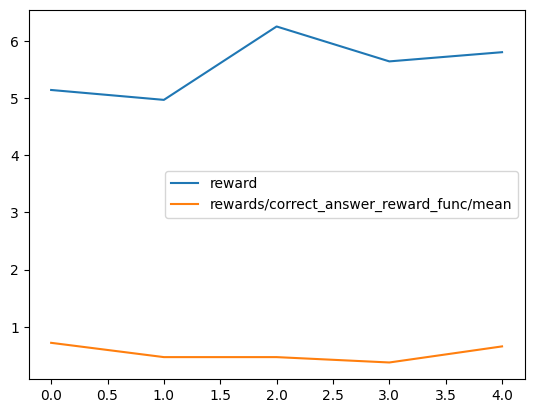

In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [ ]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
# TODO: Fill out the areas where you find **********

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Configure the maximum number of steps to take about 30mins of time for
    # a medium-sized experiment. (See how long the previous example took and
    # scale up appropriately using your best guess.)
    max_steps=68,  # ~60min
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 68
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of "g" in the word "glisten"
1. g - 1 so far
2. l - 0 so far (no l's in the word)
3. e - 0 so far (no e's in the word)
4. n - 0 so far (no n's in the word)
5. s - 1 so far
6. i - 0 so far (no i's in the word)
7. t - 1 so far
8. n - 1 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.000000,5.110714,1.929837,80.687500,41.000000,132.000000,0.000000,80.687500,41.000000,132.000000,0.000000,0.811607,0.319298,3.312500,2.249552,-0.232143,0.411651,0.500000,0.000000,0.718750,0.456803
2,0.000000,6.247954,1.180991,76.562500,53.000000,116.000000,0.000000,76.562500,53.000000,116.000000,0.000000,0.996094,0.022097,4.031250,1.768622,0.189360,0.505877,0.500000,0.000000,0.531250,0.507007
3,0.000000,6.998859,2.061492,86.000000,40.000000,113.000000,0.000000,86.000000,40.000000,113.000000,0.000000,0.955357,0.159977,4.812500,2.070336,0.106002,0.671161,0.500000,0.000000,0.625000,0.491869
4,0.000000,7.639584,1.101340,74.156250,53.000000,103.000000,0.000000,74.156250,53.000000,103.000000,0.000000,0.958333,0.103695,5.343750,2.252015,0.150000,0.508000,0.500000,0.000000,0.687500,0.470929
5,0.000000,5.361012,1.914323,75.718750,26.000000,127.000000,0.000000,75.718750,26.000000,127.000000,0.000000,0.791667,0.357948,3.437500,2.327085,0.038095,0.542922,0.500000,0.000000,0.593750,0.498991
6,-0.000000,6.101116,1.466299,73.750000,42.000000,105.000000,0.000000,73.750000,42.000000,105.000000,0.000000,0.886384,0.272151,3.843750,1.885588,0.245982,0.604703,0.500000,0.000000,0.625000,0.491869
7,0.000000,5.469494,1.901552,72.781250,53.000000,133.000000,0.000000,72.781250,53.000000,133.000000,0.000000,0.915179,0.124959,3.468750,1.866243,0.054315,0.420544,0.500000,0.000000,0.531250,0.507007
8,0.000000,6.559375,1.304522,88.656250,62.000000,126.000000,0.000000,88.656250,62.000000,126.000000,0.000000,0.967262,0.075957,4.093750,1.488870,0.498363,0.449059,0.500000,0.000000,0.500000,0.508000
9,0.000000,4.805109,1.687691,92.656250,53.000000,200.000000,0.062500,85.500008,53.000000,131.000000,0.000000,0.964286,0.080685,3.156250,1.393750,-0.377927,0.394985,0.468750,0.122967,0.593750,0.498991
10,-0.000000,6.550286,1.661253,79.593750,53.000000,179.000000,0.000000,79.593750,53.000000,179.000000,0.000000,0.933036,0.353641,3.843750,2.096224,0.492250,0.493272,0.500000,0.000000,0.781250,0.420013



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. f - 0 so far
6. l - 0 so far
7. y - 0 so far
Therefore, the letter "e" appears 1 time in the word "sapphire".
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "y" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. a - 1 so far
2. b - 1 so far
3. s - 1 so far
4. o - 1 so far
5. v - 1 so far
6. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: False!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
1. m - 1 so far
2. i - 1 so far
3. r - 0 so far
4. a - 2 so far
5. g - 1 so far
6. e - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
   

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


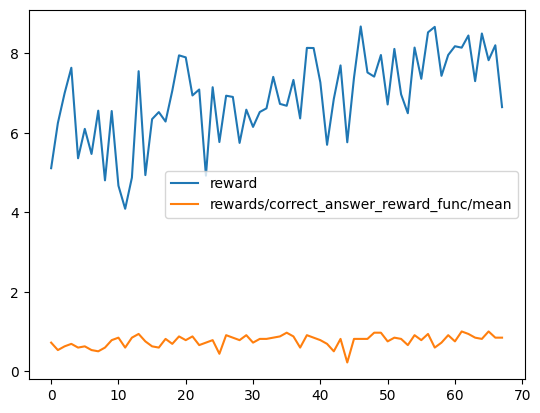

In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [ ]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_pretrained("grpo_saved_lora")
tokenizer.save_pretrained("grpo_saved_lora")

('grpo_saved_lora/tokenizer_config.json',
 'grpo_saved_lora/special_tokens_map.json',
 'grpo_saved_lora/chat_template.jinja',
 'grpo_saved_lora/vocab.json',
 'grpo_saved_lora/merges.txt',
 'grpo_saved_lora/added_tokens.json',
 'grpo_saved_lora/tokenizer.json')

In [ ]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell

from typing import Dict

def compare_old_vs_trained_model(
    base_model,
    base_tokenizer,
    lora_adapter_path: str = "grpo_saved_lora",
    user_prompt: str = "What is the capital of France",
    system_prompt: str = None,
    max_seq_length=2048,
    lora_rank=32,
    generation_params=None
  ) -> Dict[str, str]:
    """Compare base pretrained model vs LORA-trained model
    Args:
        base_model_name: HuggingFace model identifier
        lora_adapter_path: Path where LoRA adapter was saved
        user_prompt: Question to test both models
        system_prompt: System prompt for chat template
        max_seq_length: Maximum sequence length
        lora_rank: LoRA rank used during training
        generation_params: Dict of generation parameters
    """
    if system_prompt is None:
        system_prompt = "You are an AI assistant, always break down your task into steps-by-step.\
        Analyze each step with best practices, apply the best practice, test your solution before applying final solution."

    if generation_params is None:
        generation_params = {
            "max_new_tokens": 2048,
            "do_sample": True,
            "temperature": 0.8,
            "top_p": 1.0,
        }

    print("-"*50)
    print("STEP 1: Loading BASE (Pretrained Model)")

    # Load the base model without LORA
    FastLanguageModel.for_inference(base_model)

    text = base_tokenizer.apply_chat_template(
        conversation=[
            {"role":"system", "content": system_prompt},
            {"role":"user", "content": user_prompt}
        ],
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = base_tokenizer(text, return_tensors="pt").to(base_model.device)

    with torch.no_grad():
        base_output = base_model.generate(
            **inputs,
            pad_token_id=base_tokenizer.pad_token_id,
            eos_token_id=base_tokenizer.eos_token_id,
            **generation_params
        )

    base_response = base_tokenizer.decode(base_output[0], skip_special_tokens=True)

    print("BASE Model Response:")
    print("-" * 50)
    print(base_response)
    print("-" * 50)


    torch.cuda.empty_cache()

    print("STEP 3: Loading TRAINED Model (Base + LoRA Adapter)")
    print("-" * 50)

    trained_model = base_model
    trained_tokenizer = base_tokenizer

    trained_model.load_adapter(lora_adapter_path, adapter_name="default")

    FastLanguageModel.for_inference(trained_model)

    print("-" * 50)
    print("STEP 4: Testing TRAINED Model")

    inputs = trained_tokenizer(text, return_tensors="pt").to(trained_model.device)

    with torch.no_grad():
        trained_output = trained_model.generate(
            **inputs,
            pad_token_id=trained_tokenizer.pad_token_id,
            eos_token_id=trained_tokenizer.eos_token_id,
            **generation_params
        )

    trained_response = trained_tokenizer.decode(trained_output[0], skip_special_tokens=True)

    print("TRAINED Model Response:")
    print("-" * 50)
    print(trained_response)

    base_answer = base_response.replace(text, "").strip()
    trained_answer = trained_response.replace(text, "").strip()

    return {
        "question": user_prompt,
        "prompt": text,
        "base_response": base_response,
        "trained_response": trained_response,
        "base_answer": base_answer,
        "trained_answer": trained_answer,
    }


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
ls /content/drive/MyDrive/grpo_saved_lora

adapter_config.json        chat_template.jinja      tokenizer_config.json
adapter_model.safetensors  merges.txt               tokenizer.json
added_tokens.json          special_tokens_map.json  vocab.json


### Compare the old and new models on the letter-counting task

In [ ]:
# Let's try spelling the first word from the dataset
# TODO: Fill out the areas where you find **********

# Load the first item from the dataset (index 0) and compare the old and new models
# **********
ds = Dataset.from_generator(generate_records)
ds = ds.shuffle()
SYSTEM_PROMPT = f"""
Respond with the following format

<instruction>
Count each letter of the [word].
</instruction>

<reasoning>
1. [First letter]: [Count of the first letter of the word] so far
2. [Second letter]: [Count of the second letter of the word] so far
...
</reasoning>

<answer>
[number].
</answer>

"""
ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)
# Show the first item
messages = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

results = compare_old_vs_trained_model(model, tokenizer, "/content/drive/MyDrive/grpo_saved_lora", messages)
print(results)

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

--------------------------------------------------
STEP 1: Loading BASE (Pretrained Model)
BASE Model Response:
--------------------------------------------------
system
You are an AI assistant, always break down your task into steps-by-step.        Analyze each step with best practices, apply the best practice, test your solution before applying final solution.
user
system

Respond with the following format

<instruction>
Count each letter of the [word].
</instruction>

<reasoning>
1. [First letter]: [Count of the first letter of the word] so far
2. [Second letter]: [Count of the second letter of the word] so far
...
</reasoning>

<answer>
[number].
</answer>


user
How many of the letter "i" are there in the word "sphinx"
assistant

assistant
Let's analyze this step-by哇by哇步。
<instruction>
Count each letter of the [word].
</instruction>

<reasoning>
1. s: 1
2. p: 1
3. n: 1
4. f: 1
5. x: 1
6. h: 1
7. i: 0 (so far)
</reasoning>

<answer>
0.
</answer>
------------------------------------

Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [ ]:
# Let's see if the model still remembers some of the facts from its original training
# TODO: Fill out the areas where you find **********

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
question = "What is the capital of Nigeria?"

results = compare_old_vs_trained_model(model, tokenizer, "/content/drive/MyDrive/grpo_saved_lora", question)
print(results)

--------------------------------------------------
STEP 1: Loading BASE (Pretrained Model)
BASE Model Response:
--------------------------------------------------
system
You are an AI assistant, always break down your task into steps-by-step.        Analyze each step with best practices, apply the best practice, test your solution before applying final solution.
user
What is the capital of Nigeria?
assistant
To analyze and provide the correct answer to "What is the capital of Nigeria?", I will follow these steps:

Step 1: Recall the known information
- The capital city of Nigeria has already been widely recognized for many years.
- The capital is a significant administrative center with important government buildings.

Step 2: Verify the correct answer
- Based on my knowledge, the capital of Nigeria is Abuja.
  
Step 3: Confirm this answer using best practices
- Research to ensure the accuracy of the information (this step is not necessary as it's a common fact, but I'll still do a qui

Great job! Congrats on completing the project! 🎉🤗